In [1]:
import numpy as np

actual = np.array([300,250,400])
predicted = np.array([280,260,420])


residual = actual - predicted
squared_residual = residual **2
mse = squared_residual.mean()


In [2]:
(400 + 100 + 400) / 3 

300.0

In [3]:
np.random.seed(42)

house_size = np.random.uniform(800,3500,100)
noise = np.random.normal(0,20000,100)
house_price = 150 * house_size + 50000 + noise




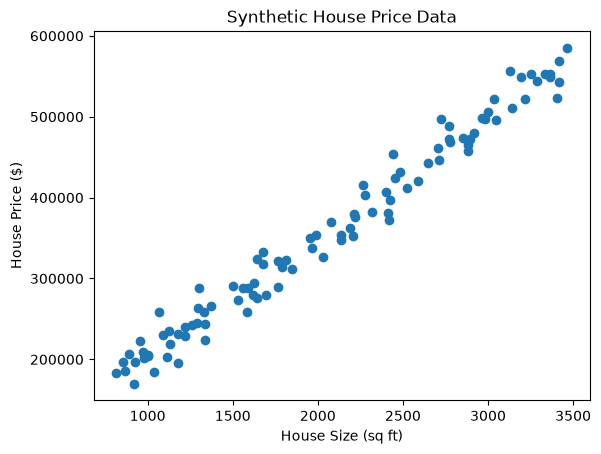

In [4]:
import matplotlib.pyplot as plt

plt.scatter(house_size,house_price)
plt.xlabel('House Size (sq ft)')
plt.ylabel('House Price ($)')
plt.title('Synthetic House Price Data')
plt.show()

In [5]:
x = np.column_stack([np.ones(len(house_size)),house_size])
Y = house_price

In [7]:
print(x.shape)
print(x[:5])

(100, 2)
[[1.00000000e+00 1.81125832e+03]
 [1.00000000e+00 3.36692863e+03]
 [1.00000000e+00 2.77638364e+03]
 [1.00000000e+00 2.41637791e+03]
 [1.00000000e+00 1.22125033e+03]]


In [8]:
print(x.dtype)

float64


In [10]:
theta =np.linalg.inv(x.T@x)@x.T @ Y
print(theta)

[57026.50523759   146.59427239]


In [11]:
theta_gd = np.zeros(2)
learning_rate = 0.0000001
n_iterations = 1000
m = len(Y)

In [12]:
loss_history = []

for i in range(n_iterations):
    predictions = x @ theta_gd
    error = predictions - Y
    gradient = (2/m) * (x.T @ error)
    theta_gd = theta_gd - learning_rate * gradient
    
    mse = (error ** 2).mean()
    loss_history.append(mse)

print(theta_gd)

[  1.55188856 170.57326532]


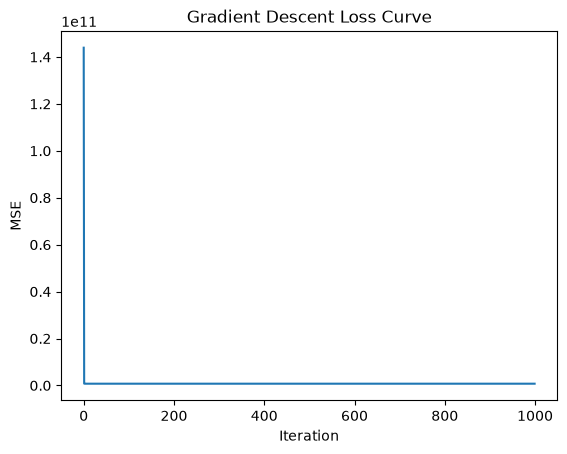

In [13]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Gradient Descent Loss Curve')
plt.show()

In [14]:
size_mean = house_size.mean()
size_std = house_size.std()
house_size_scaled = (house_size - size_mean) / size_std

x_scaled = np.column_stack([np.ones(len(house_size_scaled)), house_size_scaled])

In [15]:
theta_gd = np.zeros(2)
learning_rate = 0.01
n_iterations = 1000
m = len(Y)

loss_history = []
for i in range(n_iterations):
    predictions = x_scaled @ theta_gd
    error = predictions - Y
    gradient = (2/m) * (x_scaled.T @ error)
    theta_gd = theta_gd - learning_rate * gradient
    mse = (error ** 2).mean()
    loss_history.append(mse)

print(theta_gd)

[360401.59325828 117157.44039136]


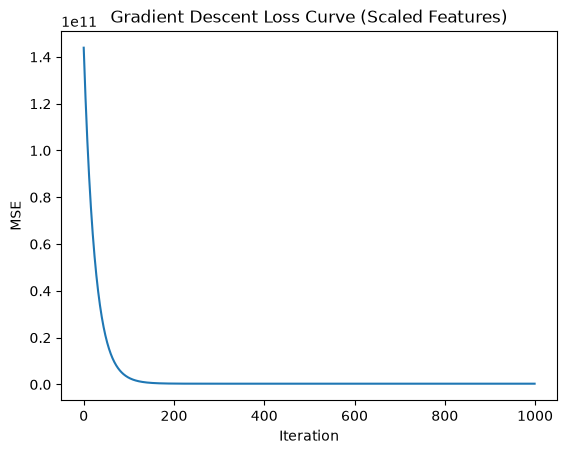

In [16]:
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Gradient Descent Loss Curve (Scaled Features)')
plt.show()